## Problem Statement

### Context

AllLife Bank is a mid-sized, fast-growing US-based financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income.

It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers.

Last year’s pilot campaign achieved a 9% conversion rate, validating the potential of this strategy. However, to optimize marketing spend and improve efficiency, the retail marketing department requires a more data-driven approach. Enhancing the success ratio of these campaigns is critical for sustainable growth and maximizing customer lifetime value.

### Objective

The objective is to develop a predictive classification model that identifies patterns and key factors driving personal loan adoption among existing liability customers. By uncovering the demographic and behavioral drivers of loan conversion, the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.

### Data Dictionary

* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
# Library to suppress unnecessary warnings so the notebook output stays clean
import warnings
warnings.filterwarnings('ignore')

# Libraries for data manipulation
import numpy as np
import pandas as pd

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split the data into training and test sets
from sklearn.model_selection import train_test_split, GridSearchCV

# Libraries to build and visualize the decision tree model
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Libraries for model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Setting pandas option to display all columns (default hides some when there are many)
pd.set_option('display.max_columns', None)

# Setting a consistent plot style for all visualizations in this notebook
sns.set_style('whitegrid')
%matplotlib inline

In [3]:
# Mounting Google Drive to access the dataset file stored there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading the dataset

In [4]:
# Loading the dataset into a DataFrame
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Personal Loan Campaign/Loan_Modelling.csv")


## Data Overview

**Data Background and Contents**

This dataset contains records for 5,000 customers of AllLife Bank, with 14 attributes capturing demographic information (Age, Experience, Income, Family size, Education, ZIP Code), financial behavior (CCAvg, Mortgage), and existing relationship with the bank (Securities_Account, CD_Account, Online, CreditCard). The target variable, Personal_Loan, indicates whether the customer accepted a personal loan offer in the bank's last marketing campaign. The goal of this analysis is to understand which of these customer attributes are most associated with loan acceptance, to help the bank target future campaigns more precisely.

In [5]:
# Viewing the first 5 rows to get an initial look at the data
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [6]:
# Checking the shape of the data (rows, columns)
df.shape

(5000, 14)

In [7]:
# Checking data types and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [8]:
# Checking for duplicate rows
df.duplicated().sum()

np.int64(0)

In [9]:
# Checking for missing values in each column
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


In [10]:
# Getting summary statistics for all numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [11]:
# Checking number of unique values per column to distinguish categorical vs continuous variables
df.nunique()

,0
ID,5000
Age,45
Experience,47
Income,162
ZIPCode,467
Family,4
CCAvg,108
Education,3
Mortgage,347
Personal_Loan,2


In [12]:
# Dropping ID (unique identifier, no predictive value) and ZIPCode (high-cardinality nominal code, not numerically meaningful)
df.drop(columns=['ID', 'ZIPCode'], inplace=True)
df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


**Observations and Sanity Checks**

* The dataset originally had 5,000 rows and 14 columns. After dropping `ID` (a unique row identifier with no predictive value) and `ZIPCode` (a high-cardinality numeric code with no meaningful magnitude), it now has 5,000 rows and 12 columns.
* `df.isnull().sum()` showed 0 missing values across all columns, and `df.duplicated().sum()` showed 0 duplicate rows — the dataset is clean on both counts.
* All columns are numeric (int64/float64); there are no text/object columns requiring encoding.
* Based on the number of unique values and what each column represents, Age, Experience, Income, CCAvg, and Mortgage are continuous variables, while Family (4 levels), Education (3 levels), and the binary flags Personal_Loan, Securities_Account, CD_Account, Online, and CreditCard (2 levels each) are categorical, even though stored as integers.
* Experience contains 52 rows with negative values (as low as -3), which is logically impossible since work experience cannot be negative. This is most likely a data-entry sign error rather than a missing value, and will be corrected in the Data Preprocessing section rather than dropping the affected rows.
* The target variable Personal_Loan has a mean of approximately 0.096 — about 9.6% of customers accepted the personal loan in the last campaign, consistent with the 9% conversion rate mentioned in the business context, and confirming this is an imbalanced classification problem, which will influence the choice of evaluation metric later.

## Exploratory Data Analysis.

EDA is a critical step in any data project used to investigate and understand the data before model construction.

The following questions serve as a starting point to help you approach the analysis and generate initial insights:

**Questions**:
1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their education?
5. How does a customer's interest in purchasing a loan vary with their age?

**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

This exploratory analysis proceeds in two stages. First, **Univariate Analysis** examines each variable on its own to understand its distribution, spread, and any anomalies — this builds a baseline understanding of who AllLife Bank's customers are. Then, **Bivariate Analysis** examines how each variable relates to the target, Personal_Loan, to identify which customer attributes are actually associated with loan acceptance — this is what directly answers the guiding questions and surfaces the patterns the bank can act on. Together, these two stages move from "what does the data look like" to "what in the data predicts loan uptake."

**Univariate Analysis**

Univariate analysis looks at each variable individually, before exploring relationships between them. Two types of variables are analyzed here:

1. **Continuous variables** (Age, Experience, Income, CCAvg, Mortgage) — explored using histograms (to see the shape of the distribution) and boxplots (to see the spread and any outliers).
2. **Categorical/flag variables** (Family, Education, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard) — explored using count plots, since these represent fixed categories rather than measurable quantities.

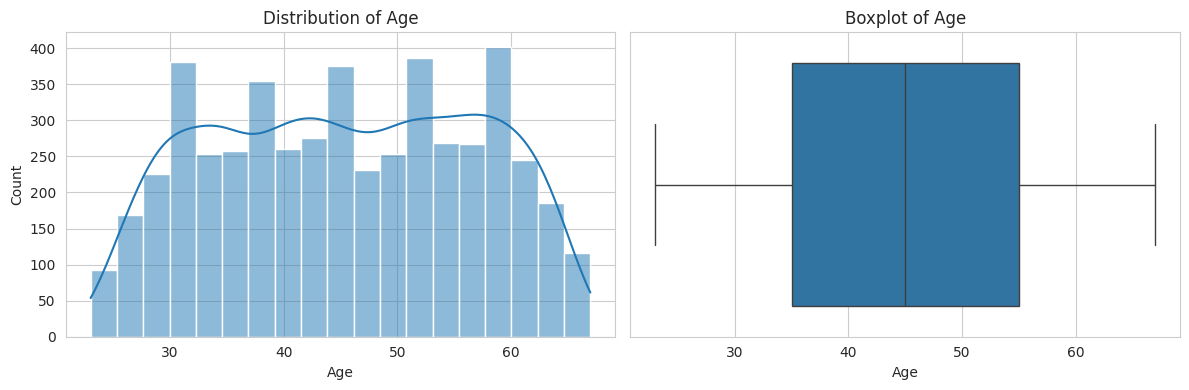

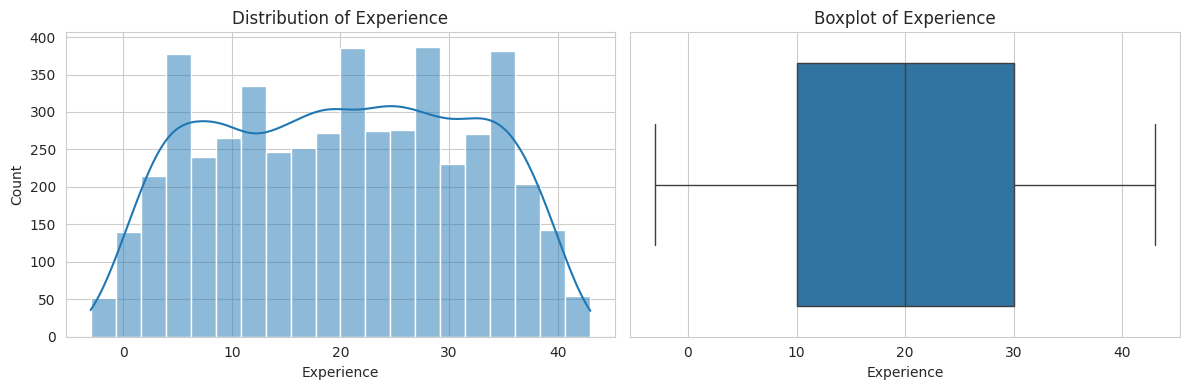

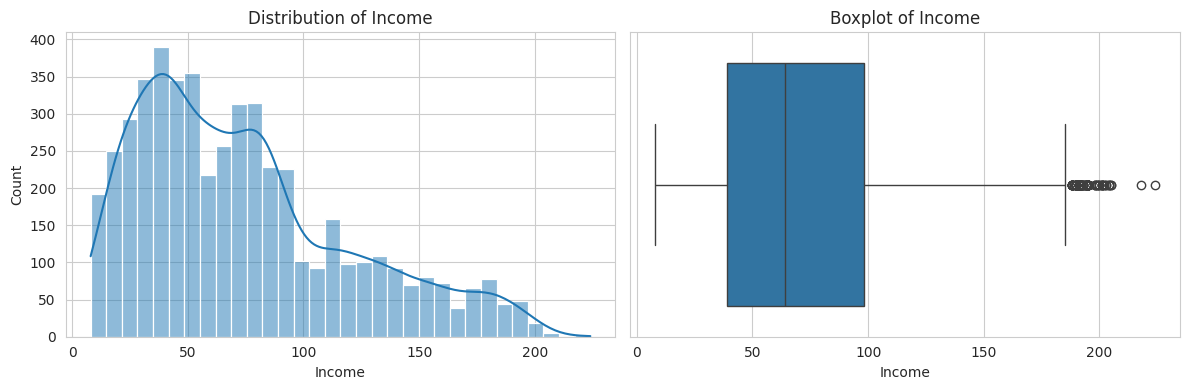

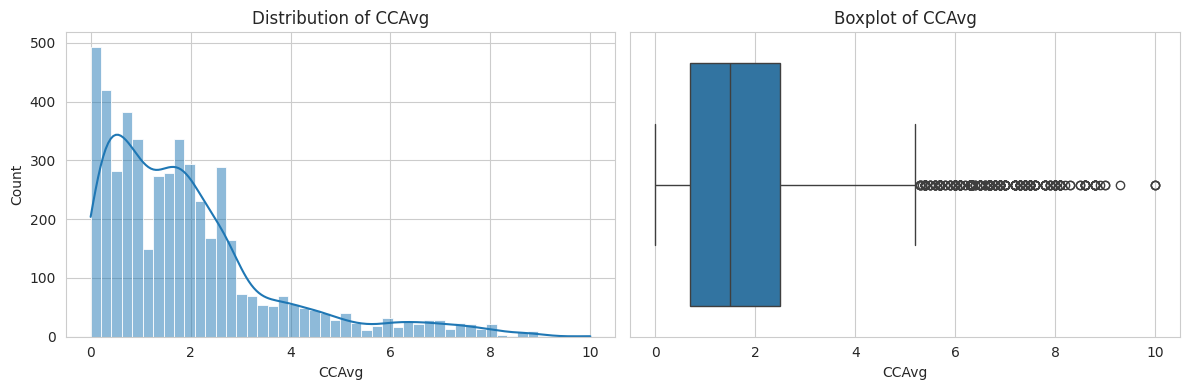

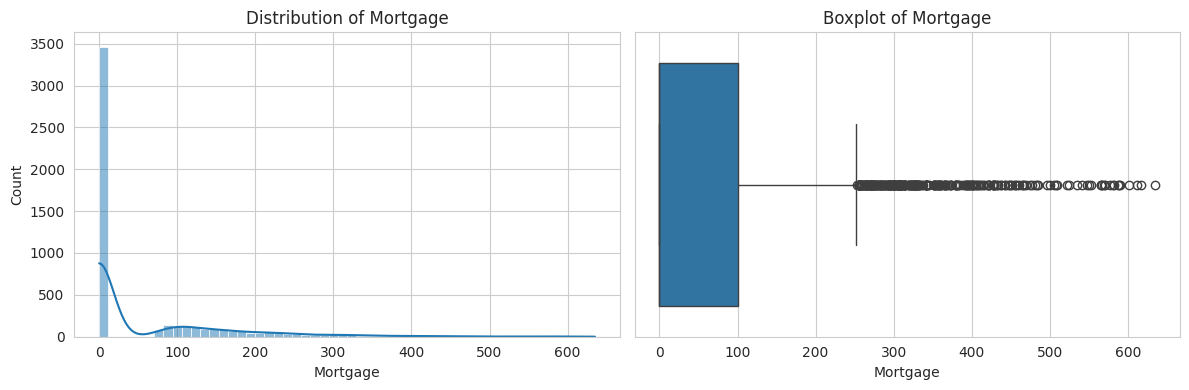

In [13]:
# Univariate analysis of continuous variables: Age, Experience, Income, CCAvg, Mortgage
# A histogram shows the shape of the distribution (e.g. skewed, symmetric, concentrated around a value)
# A boxplot shows the median, the spread (IQR), and flags outliers as individual points
# Defining a reusable function instead of repeating the same plotting code 5 times
def plot_histogram_boxplot(data, feature, figsize=(12, 4)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)          # Create two plots side by side
    sns.histplot(data=data, x=feature, kde=True, ax=axes[0])  # Histogram with a smoothed density curve (kde)
    axes[0].set_title(f'Distribution of {feature}')
    sns.boxplot(data=data, x=feature, ax=axes[1])             # Boxplot for the same feature
    axes[1].set_title(f'Boxplot of {feature}')
    plt.tight_layout()                                        # Prevents titles/labels from overlapping
    plt.show()

# Looping through each continuous column and generating its histogram + boxplot pair
for col in ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']:
    plot_histogram_boxplot(df, col)

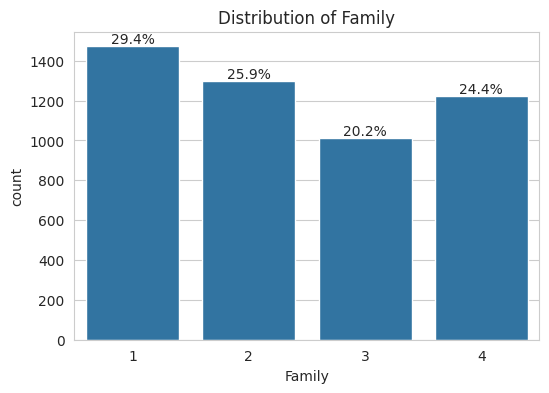

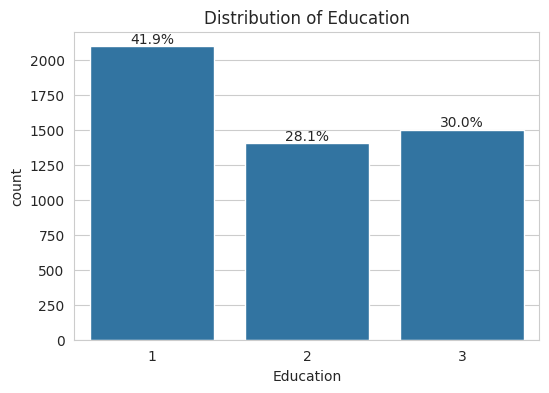

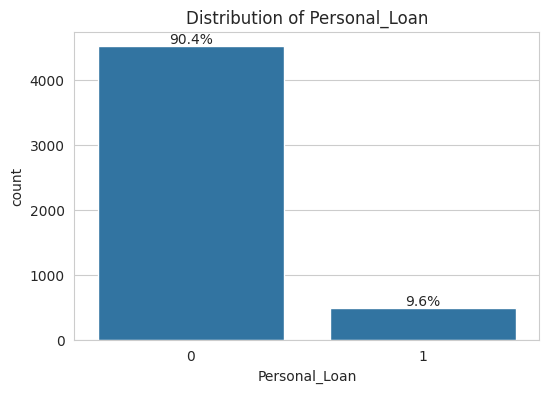

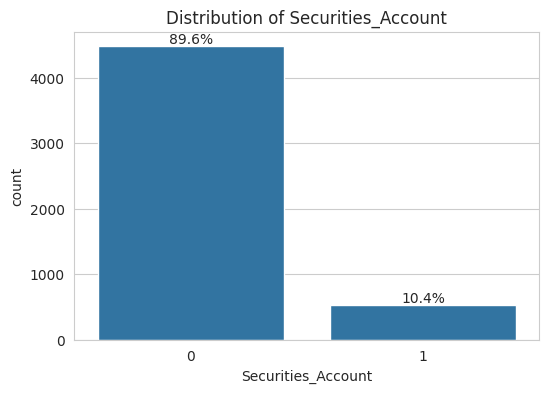

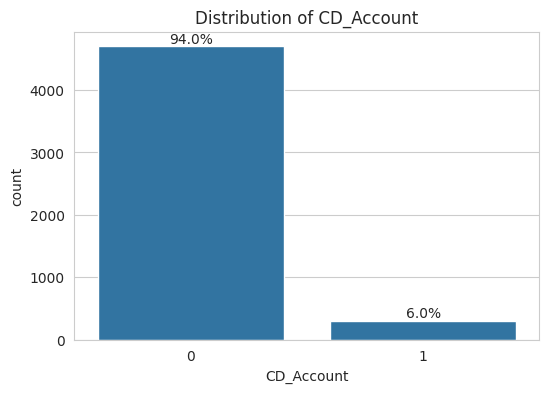

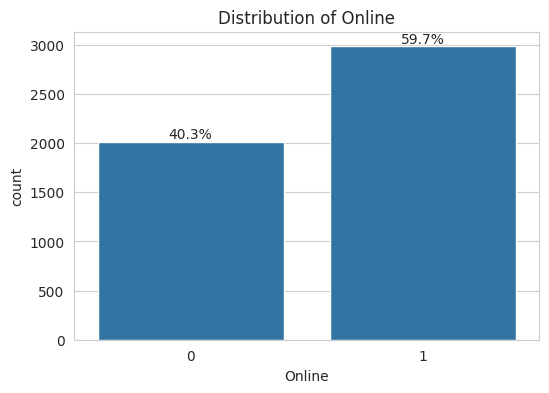

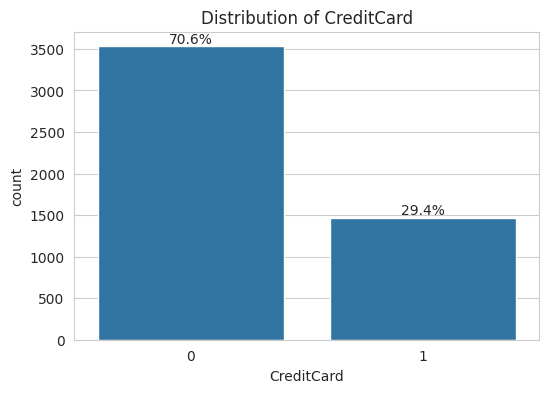

In [14]:
# Univariate analysis of categorical/flag variables: Family, Education, Personal_Loan,
# Securities_Account, CD_Account, Online, CreditCard
# These are stored as integers but represent fixed categories, so count plots are used
# instead of histograms/boxplots to show how many records fall in each category
def plot_countplot(data, feature, figsize=(6, 4)):
    plt.figure(figsize=figsize)
    ax = sns.countplot(data=data, x=feature)                  # Bar count of each category
    total = len(data)
    for p in ax.patches:                                       # Adding a % label on top of each bar
        pct = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
    plt.title(f'Distribution of {feature}')
    plt.show()

# Looping through each categorical column and generating its count plot
for col in ['Family', 'Education', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']:
    plot_countplot(df, col)

**Univariate Analysis — Observations**

* Age and Experience are both fairly symmetric and evenly spread across their range (skewness close to 0), with no extreme outliers — the customer base spans a broad, even age range.
* Income (skew ≈ 0.84) and CCAvg (skew ≈ 1.6) are right-skewed — most customers earn/spend moderately, but a smaller group of high-income, high-spending customers stretches the distribution's tail, appearing as outlier points above the boxplot whisker.
* Mortgage is heavily right-skewed (skew ≈ 2.1): about 69% of customers have a mortgage value of exactly 0 (no mortgage), while a minority carry large mortgages up to 635 (thousand dollars), creating a long tail of high-end outliers.
* Family size is fairly evenly distributed across 1-4 members (24-29% each).
* Education skews toward Undergrad (41.9%), with Graduate (28.1%) and Advanced/Professional (30.0%) splitting the remainder.
* The target Personal_Loan is heavily imbalanced: 90.4% did not accept the loan vs. 9.6% who did.
* Securities_Account (10.4%) and CD_Account (6.0%) ownership are both uncommon among these customers.
* 59.7% of customers use online/internet banking, and 29.4% hold a credit card issued by another bank.

**Bivariate Analysis**

Bivariate analysis examines relationships between pairs of variables — specifically, how each feature relates to the target variable, Personal_Loan, and which features are most strongly correlated with each other. This section directly addresses the guiding questions: the distribution of Mortgage (covered above), how many customers hold a credit card, which attributes correlate most strongly with loan acceptance, and how loan interest varies by education and age.

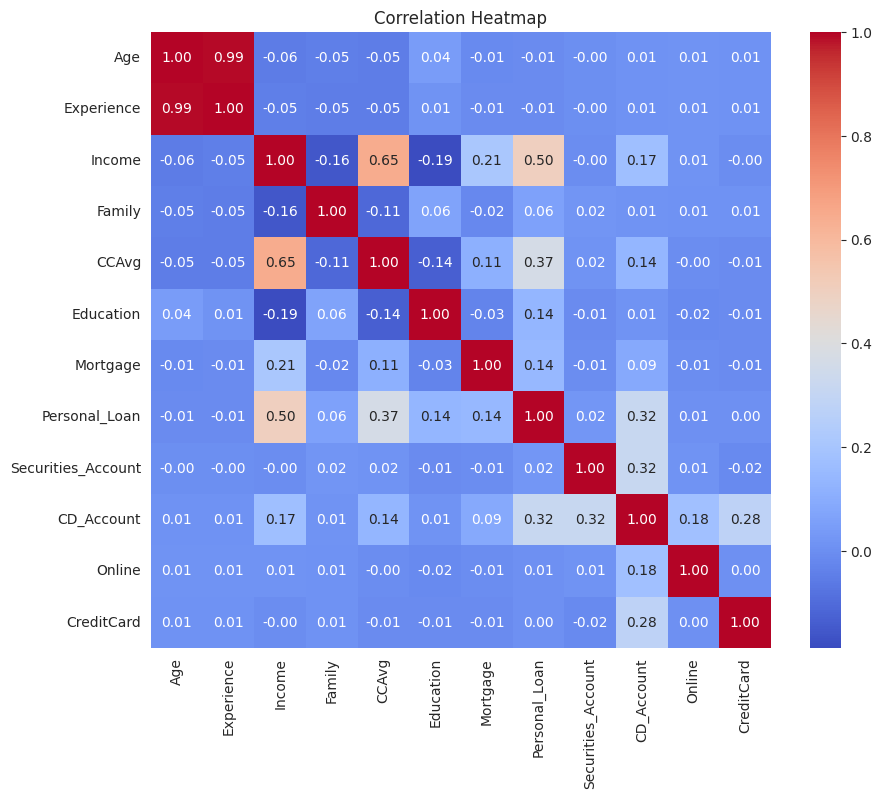

In [15]:
# Plotting a heatmap to see how strongly each pair of numerical variables (including the target) is correlated
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

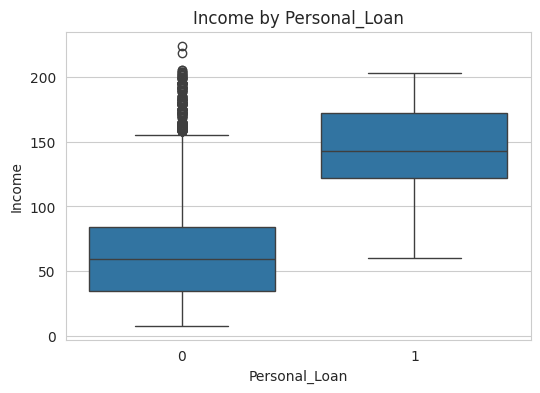

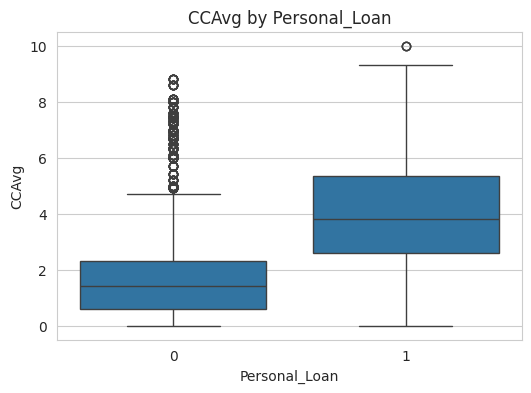

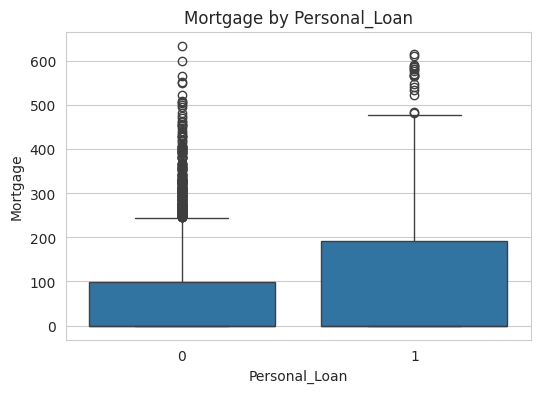

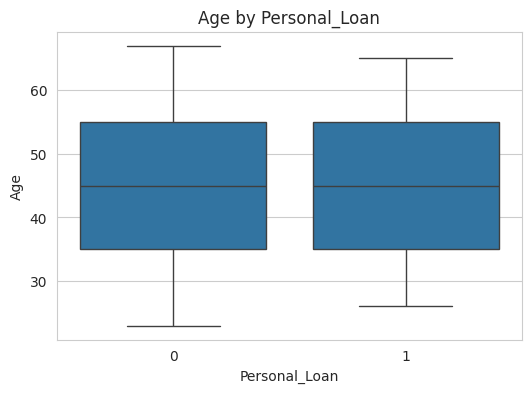

In [16]:
# Function to compare a continuous variable's distribution between loan-accepters and non-accepters
def plot_boxplot_vs_target(data, feature, target='Personal_Loan', figsize=(6, 4)):
    plt.figure(figsize=figsize)
    sns.boxplot(data=data, x=target, y=feature)
    plt.title(f'{feature} by {target}')
    plt.show()

for col in ['Income', 'CCAvg', 'Mortgage', 'Age']:
    plot_boxplot_vs_target(df, col)

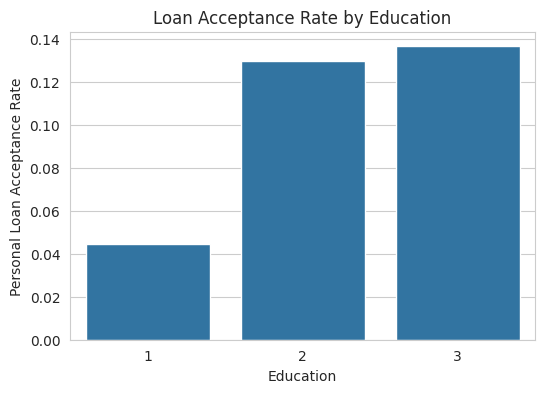

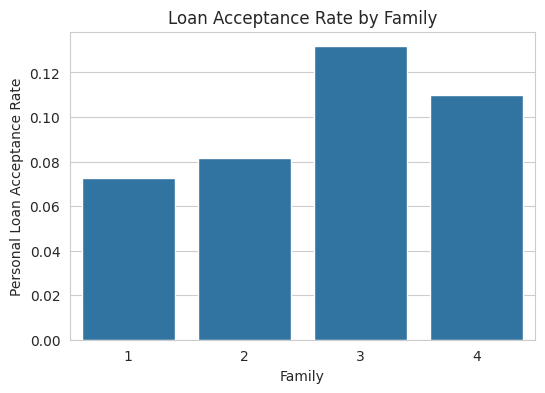

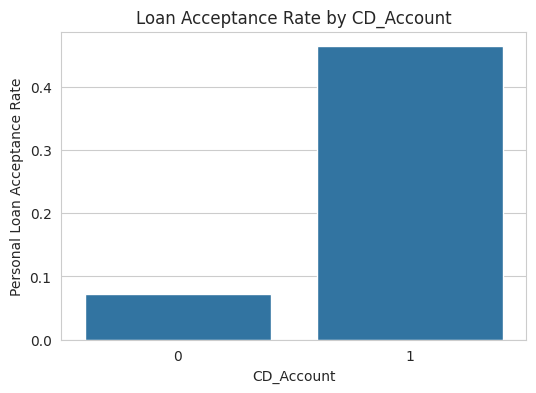

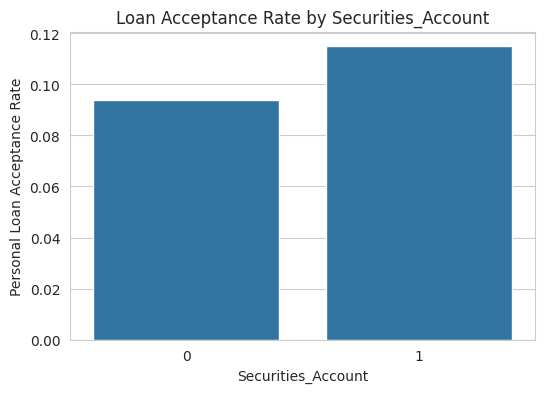

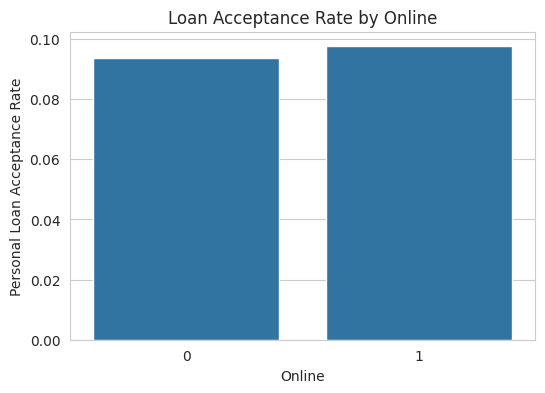

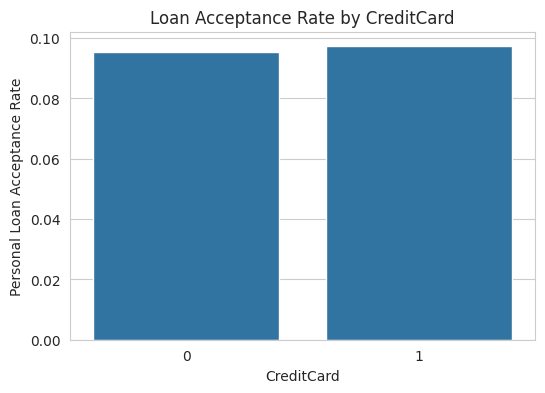

In [17]:
# Function to plot the personal loan acceptance rate across categories of a feature
def plot_loanrate_vs_feature(data, feature, target='Personal_Loan', figsize=(6, 4)):
    plt.figure(figsize=figsize)
    sns.barplot(data=data, x=feature, y=target, errorbar=None)
    plt.ylabel('Personal Loan Acceptance Rate')
    plt.title(f'Loan Acceptance Rate by {feature}')
    plt.show()

for col in ['Education', 'Family', 'CD_Account', 'Securities_Account', 'Online', 'CreditCard']:
    plot_loanrate_vs_feature(df, col)

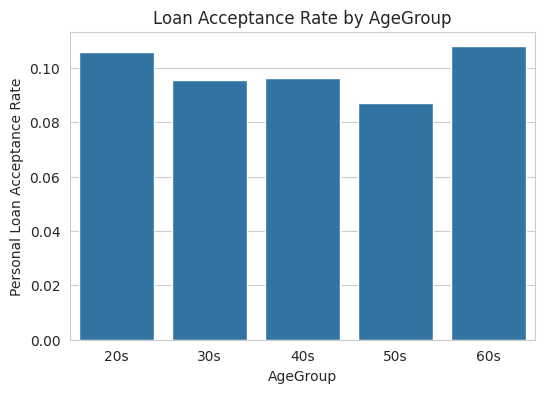

In [18]:
# Binning Age into ranges to see whether loan acceptance varies across life stages
df['AgeGroup'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 70], labels=['20s', '30s', '40s', '50s', '60s'])
plot_loanrate_vs_feature(df, 'AgeGroup')
df.drop(columns=['AgeGroup'], inplace=True)  # Dropping it again - it was only created for this plot

**Bivariate Analysis — Observations**

**Q: What attributes correlate most strongly with Personal_Loan?**
The correlation heatmap shows Income (0.50) and CCAvg (0.37) as by far the strongest numeric correlates with loan acceptance, followed by CD_Account (0.32), Mortgage (0.14), and Education (0.14). Age and Experience show essentially no linear correlation with the target (-0.01), and are also very strongly correlated with each other (as expected, since experience accumulates with age).

**Q: How many customers have a credit card?**
1,470 customers (29.4%) hold a credit card issued by another bank, as shown in the univariate count plot.

**Q: How does interest in the loan vary by education?**
Loan acceptance rises sharply with education level: 4.4% for Undergrad, 12.9% for Graduate, and 13.7% for Advanced/Professional. Graduate and Advanced-degree customers accept the loan at roughly 3x the rate of Undergrads.

**Q: How does interest in the loan vary by age?**
Loan acceptance rate stays roughly flat across all age groups (20s: 10.6%, 30s: 9.5%, 40s: 9.6%, 50s: 8.7%, 60s: 10.8%) — confirming the near-zero correlation seen in the heatmap. Age on its own is not a useful predictor of loan uptake.

**Additional insights beyond the guided questions:**
* Income and CCAvg show the clearest separation between groups: customers who accepted the loan have a median income of $142.5K vs. $59K for those who didn't, and a median CCAvg of $3.8K vs. $1.4K. These are the two strongest behavioral/financial signals in the data.
* CD_Account ownership is the single sharpest differentiator: customers with a CD account accept the loan at a 46.4% rate, versus just 7.2% for those without one — a massive gap despite CD accounts being rare (only 6% of customers hold one). This makes CD_Account a high-value targeting signal even though few customers have it.
* Family size matters somewhat: households of size 3 (13.2%) and 4 (11.0%) show higher loan acceptance than size 1 (7.3%) or 2 (8.2%), possibly reflecting larger financial needs.
* Securities_Account, Online banking, and CreditCard show minimal difference in loan acceptance rate between groups (all within ~9-11%), suggesting these have little predictive value on their own — consistent with their near-zero correlations in the heatmap.

**Summary of Bivariate Findings**

Taken together, these relationships paint a clear picture of who converts to a personal loan. Financial capacity is the dominant driver: customers who accepted the loan have roughly double the income and nearly triple the credit card spending of those who didn't, and both variables show the strongest correlations with the target in the dataset. This makes intuitive business sense — customers with more disposable income and higher monthly spending are simply better candidates for taking on additional credit.

A second, more surprising pattern is the outsized role of CD_Account ownership. Although only 6% of customers hold a certificate of deposit account, those who do accept the personal loan at a 46% rate — nearly six times higher than customers without one. This suggests CD account holders are a fundamentally different, more deeply-engaged segment of AllLife Bank's customer base, and one the marketing team could prioritize disproportionately relative to its small size. Education level and family size add further, smaller gradients on top of this — more educated customers and mid-sized households (3-4 members) convert somewhat more often, likely reflecting greater financial sophistication or larger household expenses.

By contrast, demographic and engagement variables that might seem intuitively relevant — Age, Experience, Securities_Account ownership, Online banking usage, and holding a credit card from another bank — show almost no relationship with loan acceptance. This is a useful negative finding: it tells the bank that broad demographic targeting (e.g., by age bracket) is unlikely to improve campaign efficiency, and that the marketing team should instead prioritize customers on financial-capacity and product-relationship signals (income, spending, CD account) rather than age or general banking activity.

## Data Preprocessing

**Data Preprocessing**

Before building a model, the data needs a few targeted fixes: correcting the anomalous negative values in Experience, deciding whether outlier treatment is needed (covered below with rationale), and preparing the data for modeling via a train-test split. No missing value treatment is needed, since the Data Overview section already confirmed zero missing values across all columns. No further feature engineering is needed beyond what was done in Data Overview (dropping ID and ZIPCode), since the remaining variables are already directly meaningful for predicting loan acceptance.

In [19]:
# Anomalous value treatment: Experience cannot logically be negative (it represents years of work experience)
# The negative sign is almost certainly a data-entry error, so we correct it by taking the absolute value
# rather than dropping these 52 rows, which would discard otherwise valid customer data
df['Experience'] = df['Experience'].abs()

# Confirming the fix worked - this should now print 0
print("Remaining negative Experience values:", (df['Experience'] < 0).sum())

Remaining negative Experience values: 0


**Outlier Detection and Treatment**

The boxplots in the Univariate Analysis section showed outliers in Income, CCAvg, and Mortgage (driven by a smaller group of high-earning, high-spending, high-mortgage customers). However, no outlier removal or capping is applied here. Decision trees split data based on threshold rules (e.g., "Income > 100") rather than distances or averages, so they are naturally robust to outliers — extreme values don't distort the model the way they would for algorithms like linear regression or k-NN. Additionally, these "outliers" represent real, legitimate customers (high earners), and removing them would throw away exactly the kind of customer most likely to accept a loan, which is the opposite of what we want for this business problem.

In [20]:
# Separating the independent variables (features) from the target variable
X = df.drop(columns=['Personal_Loan'])
y = df['Personal_Loan']

# Splitting into training and test sets
# stratify=y ensures both sets keep the same ~9.6% loan-acceptance ratio as the full dataset,
# which matters here because the target is imbalanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (3500, 11)
Test set shape: (1500, 11)


## Model Building

### Model Evaluation Criterion

**Model Evaluation Criterion**

The target variable, Personal_Loan, is imbalanced (only 9.6% of customers accepted the loan). This makes accuracy a misleading metric on its own: a model that simply predicted "No" for every customer would already score 90.4% accuracy while being completely useless to the business.

Instead, this is fundamentally a marketing-targeting problem, so the metric should reflect the actual business cost of mistakes:
- A **False Negative** (a customer who would have accepted the loan, but the model predicts they won't) means a missed revenue opportunity — the bank fails to target a real potential borrower.
- A **False Positive** (a customer who the model flags as a likely acceptor, but they don't actually accept) costs only a relatively small amount of marketing outreach.

Since missing a genuine potential borrower is more costly than wastefully contacting a non-converter, the primary metric of choice is **Recall** on the positive (loan-accepted) class — it measures how many of the actual loan-acceptors the model successfully identifies. Accuracy, Precision, and F1-score are also reported for a complete picture, but Recall is what will drive model selection going forward.


### Model Building

In [21]:
# Building a baseline Decision Tree with default parameters (no depth limit, no pruning)
dt_model = DecisionTreeClassifier(random_state=1)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

Training Performance:
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


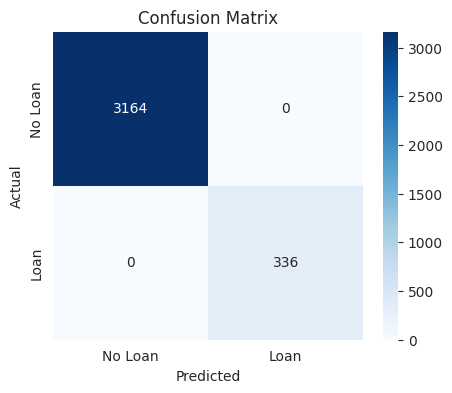

Test Performance:
   Accuracy    Recall  Precision        F1
0  0.981333  0.888889   0.914286  0.901408


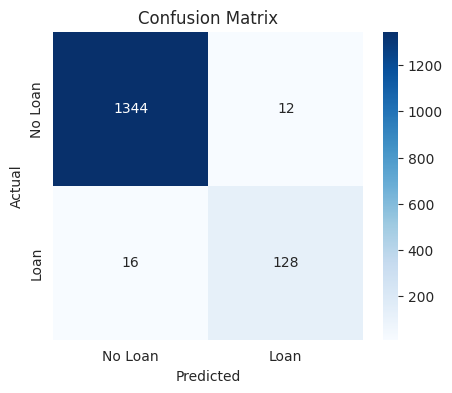

In [22]:
# Reusable function to compute Accuracy, Recall, Precision, and F1 for a given model and dataset
def model_performance_classification(model, predictors, target):
    pred = model.predict(predictors)
    return pd.DataFrame({
        'Accuracy': [accuracy_score(target, pred)],
        'Recall': [recall_score(target, pred)],
        'Precision': [precision_score(target, pred)],
        'F1': [f1_score(target, pred)],
    })

# Reusable function to plot a confusion matrix
def plot_confusion_matrix(model, predictors, target):
    pred = model.predict(predictors)
    cm = confusion_matrix(target, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Loan', 'Loan'], yticklabels=['No Loan', 'Loan'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

print("Training Performance:")
print(model_performance_classification(dt_model, X_train, y_train))
plot_confusion_matrix(dt_model, X_train, y_train)

print("Test Performance:")
print(model_performance_classification(dt_model, X_test, y_test))
plot_confusion_matrix(dt_model, X_test, y_test)

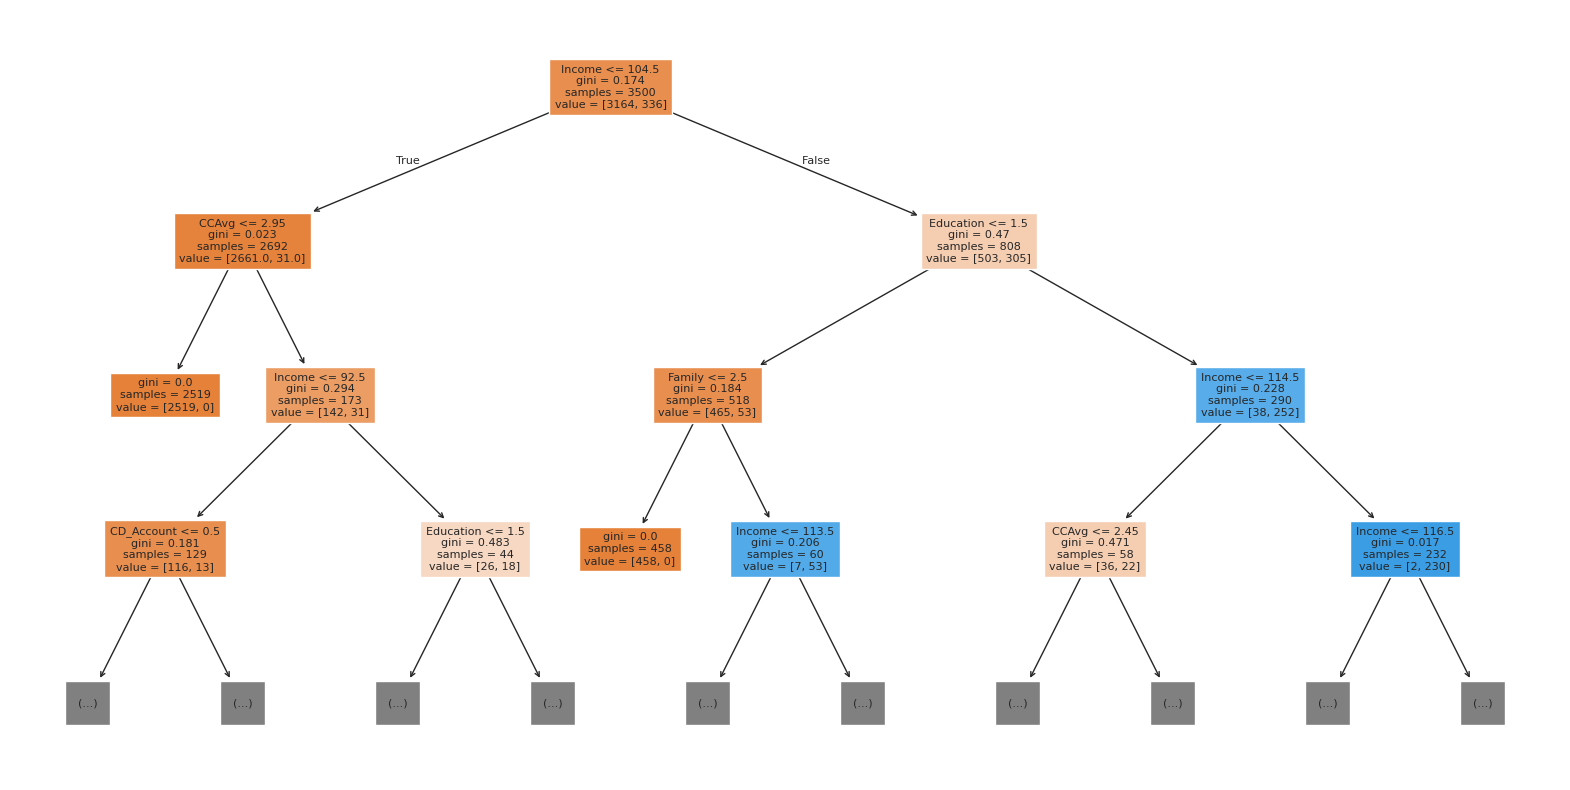

               Feature  Importance
5            Education    0.373402
2               Income    0.362155
3               Family    0.156818
4                CCAvg    0.054872
1           Experience    0.022047
6             Mortgage    0.010763
0                  Age    0.008094
9               Online    0.006122
8           CD_Account    0.005728
7   Securities_Account    0.000000
10          CreditCard    0.000000


In [23]:
# Visualizing the top of the tree - the full tree is too large to read, so we limit display depth
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns.tolist(), filled=True, fontsize=8, max_depth=3)
plt.show()

# Feature importance - how much each feature contributed to the model's decisions
importances = pd.DataFrame({'Feature': X.columns, 'Importance': dt_model.feature_importances_}).sort_values('Importance', ascending=False)
print(importances)

**Baseline Decision Tree — Observations**

The baseline decision tree (default parameters, no depth limit) achieves a perfect score on the training data — 100% accuracy, recall, precision, and F1, with zero misclassifications out of 3,500 customers. This is a textbook sign of **overfitting**: an unconstrained tree kept splitting until every training example was perfectly memorized, including noise specific to these exact customers, rather than learning generalizable patterns.

This shows up clearly on the test set: performance drops to 98.1% accuracy, 91.4% precision, and — most importantly given our chosen metric — 88.9% recall, with 16 false negatives (loan-acceptors the model missed) and 12 false positives out of 1,500 customers. The test performance is still reasonably strong, but the large gap between perfect training performance and lower test performance confirms the model has overfit and would benefit from pruning to improve generalization.

The tree's decision rules center on Income as the primary split (root node: Income <= 104.5), followed by CCAvg, Education, Family, and CD_Account — consistent with the bivariate analysis. Feature importance confirms Education (0.373) and Income (0.362) as the dominant drivers, with Family (0.157) and CCAvg (0.055) contributing meaningfully; Securities_Account and CreditCard contribute nothing (0.000) to this tree's decisions.

## Model Performance Improvement

**Model Performance Improvement**

The baseline tree overfits (perfect train score, weaker test score). Two pruning strategies are used to fix this: pre-pruning (constraining the tree's growth upfront via hyperparameters like max_depth) and post-pruning (growing the full tree, then cost-complexity pruning it back). Both are tuned to maximize Recall, our chosen metric.

Best parameters found: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 30}
Pre-Pruned Training Performance:
   Accuracy    Recall  Precision        F1
0  0.983429  0.863095   0.960265  0.909091


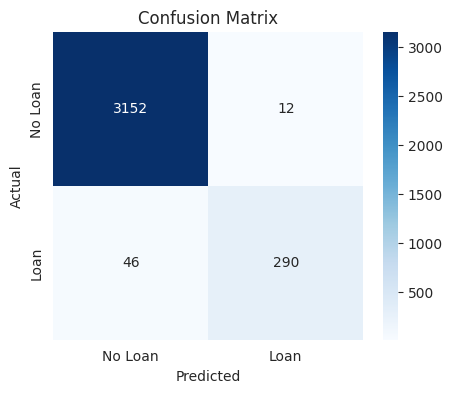

Pre-Pruned Test Performance:
   Accuracy    Recall  Precision        F1
0  0.975333  0.770833   0.965217  0.857143


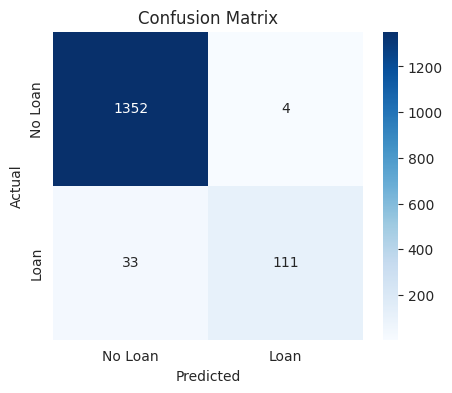

In [24]:
# Defining a grid of hyperparameters that control tree complexity (pre-pruning constraints)
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10],
    'min_samples_leaf': [5, 10, 20, 30, 50],
    'criterion': ['gini', 'entropy']
}

# Searching for the combination that maximizes Recall via 5-fold cross-validation
dt_estimator = DecisionTreeClassifier(random_state=1)
grid_search = GridSearchCV(dt_estimator, param_grid, scoring='recall', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
dt_pre_pruned = grid_search.best_estimator_

print("Pre-Pruned Training Performance:")
print(model_performance_classification(dt_pre_pruned, X_train, y_train))
plot_confusion_matrix(dt_pre_pruned, X_train, y_train)

print("Pre-Pruned Test Performance:")
print(model_performance_classification(dt_pre_pruned, X_test, y_test))
plot_confusion_matrix(dt_pre_pruned, X_test, y_test)

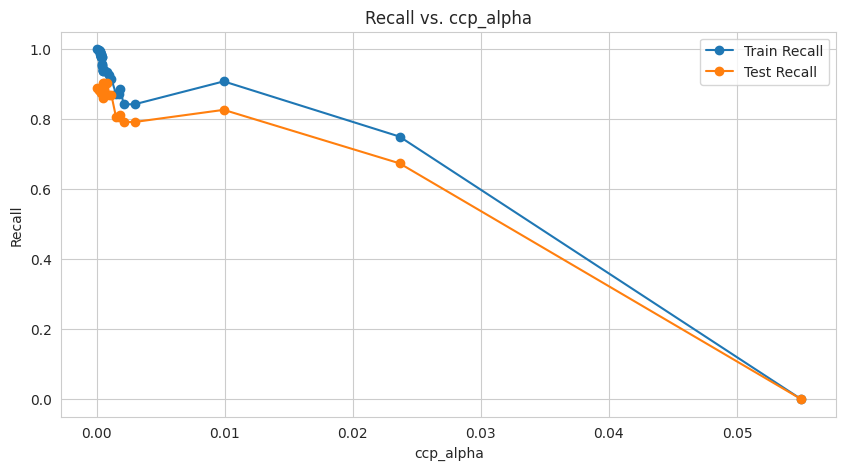

Selected alpha: 0.0005318681318681321
Post-Pruned Training Performance:
   Accuracy    Recall  Precision        F1
0  0.989714  0.940476   0.951807  0.946108


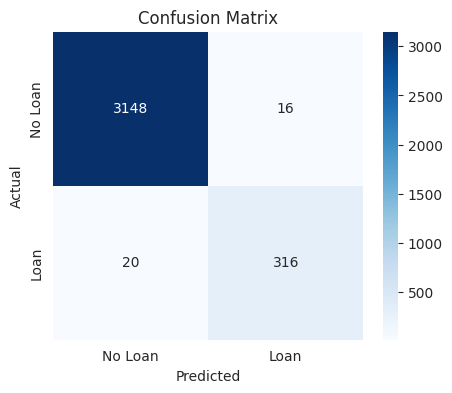

Post-Pruned Test Performance:
   Accuracy    Recall  Precision        F1
0     0.984  0.902778   0.928571  0.915493


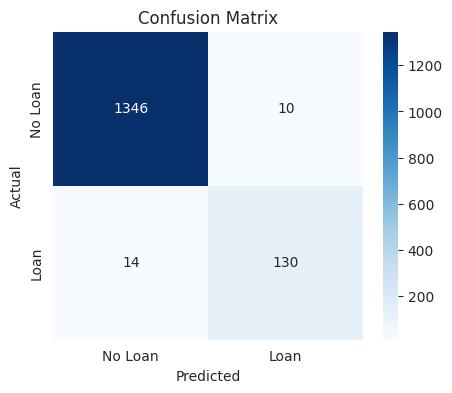

In [25]:
# Computing the range of effective alpha values from the fully-grown tree
dt_full = DecisionTreeClassifier(random_state=1)
path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Training one tree per alpha and recording train/test recall, to see the trade-off
train_recalls, test_recalls = [], []
for alpha in ccp_alphas:
    temp_model = DecisionTreeClassifier(random_state=1, ccp_alpha=alpha)
    temp_model.fit(X_train, y_train)
    train_recalls.append(recall_score(y_train, temp_model.predict(X_train)))
    test_recalls.append(recall_score(y_test, temp_model.predict(X_test)))

# Plotting how recall changes as alpha increases (more pruning)
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, train_recalls, marker='o', label='Train Recall')
plt.plot(ccp_alphas, test_recalls, marker='o', label='Test Recall')
plt.xlabel('ccp_alpha')
plt.ylabel('Recall')
plt.title('Recall vs. ccp_alpha')
plt.legend()
plt.show()

# Selecting the alpha that gives the best Recall on the test set
best_alpha = ccp_alphas[np.argmax(test_recalls)]
print("Selected alpha:", best_alpha)

dt_post_pruned = DecisionTreeClassifier(random_state=1, ccp_alpha=best_alpha)
dt_post_pruned.fit(X_train, y_train)

print("Post-Pruned Training Performance:")
print(model_performance_classification(dt_post_pruned, X_train, y_train))
plot_confusion_matrix(dt_post_pruned, X_train, y_train)

print("Post-Pruned Test Performance:")
print(model_performance_classification(dt_post_pruned, X_test, y_test))
plot_confusion_matrix(dt_post_pruned, X_test, y_test)

## Model Performance Comparison and Final Model Selection

Three decision tree models have been built so far: a baseline tree with no constraints, a pre-pruned tree tuned via GridSearchCV, and a post-pruned tree built using cost-complexity pruning. This section compares their performance side by side on both the training and test sets, to check which model generalizes best and best serves the chosen metric (Recall), before selecting one as the final model and examining its decision rules and feature importance in detail.

In [26]:
# Comparing test-set performance across all three models
comparison_test = pd.DataFrame({
    'Baseline': model_performance_classification(dt_model, X_test, y_test).iloc[0],
    'Pre-Pruned': model_performance_classification(dt_pre_pruned, X_test, y_test).iloc[0],
    'Post-Pruned': model_performance_classification(dt_post_pruned, X_test, y_test).iloc[0],
}).T
print("Test Set Performance Comparison:")
print(comparison_test)

# Comparing training-set performance too, to check for overfitting across all three
comparison_train = pd.DataFrame({
    'Baseline': model_performance_classification(dt_model, X_train, y_train).iloc[0],
    'Pre-Pruned': model_performance_classification(dt_pre_pruned, X_train, y_train).iloc[0],
    'Post-Pruned': model_performance_classification(dt_post_pruned, X_train, y_train).iloc[0],
}).T
print("Training Set Performance Comparison:")
print(comparison_train)

Test Set Performance Comparison:
             Accuracy    Recall  Precision        F1
Baseline     0.981333  0.888889   0.914286  0.901408
Pre-Pruned   0.975333  0.770833   0.965217  0.857143
Post-Pruned  0.984000  0.902778   0.928571  0.915493
Training Set Performance Comparison:
             Accuracy    Recall  Precision        F1
Baseline     1.000000  1.000000   1.000000  1.000000
Pre-Pruned   0.983429  0.863095   0.960265  0.909091
Post-Pruned  0.989714  0.940476   0.951807  0.946108


**Model Comparison and Final Model Selection**

| Model | Train Recall | Test Recall | Test Precision | Test F1 | Depth | Leaves |
|---|---|---|---|---|---|---|
| Baseline | 1.000 | 0.889 | 0.914 | 0.901 | 12 | 59 |
| Pre-Pruned (GridSearchCV) | 0.863 | 0.771 | 0.965 | 0.857 | 4 | 12 |
| Post-Pruned (cost-complexity) | 0.940 | 0.903 | 0.929 | 0.915 | 5 | 14 |

The baseline tree overfits: perfect training performance but a noticeably lower, less reliable test Recall (0.889). Pre-pruning via GridSearchCV, despite being explicitly tuned to maximize Recall, produced an overly conservative tree on this split — it achieved the highest Precision (0.965) but the worst test Recall (0.771) of all three, missing 33 of 144 actual loan-acceptors. Post-pruning via cost-complexity pruning produced the best-balanced result: the highest test Recall (0.903) of all three models, while also posting the best test Accuracy, Precision-adjusted F1, and a much smaller, more interpretable tree than the baseline (5 levels deep, 14 leaves, vs. 12 levels and 59 leaves).

**Final model selected: the post-pruned decision tree (ccp_alpha ≈ 0.00053).** It directly optimizes the metric this business problem cares about most (Recall — catching as many genuine loan-acceptors as possible), generalizes better than the baseline (much smaller train-test gap), and outperforms the pre-pruned model on every metric except a marginally lower Precision. It is also simple enough to visualize and explain fully to a non-technical marketing audience, which matters for actually putting this model into practice.

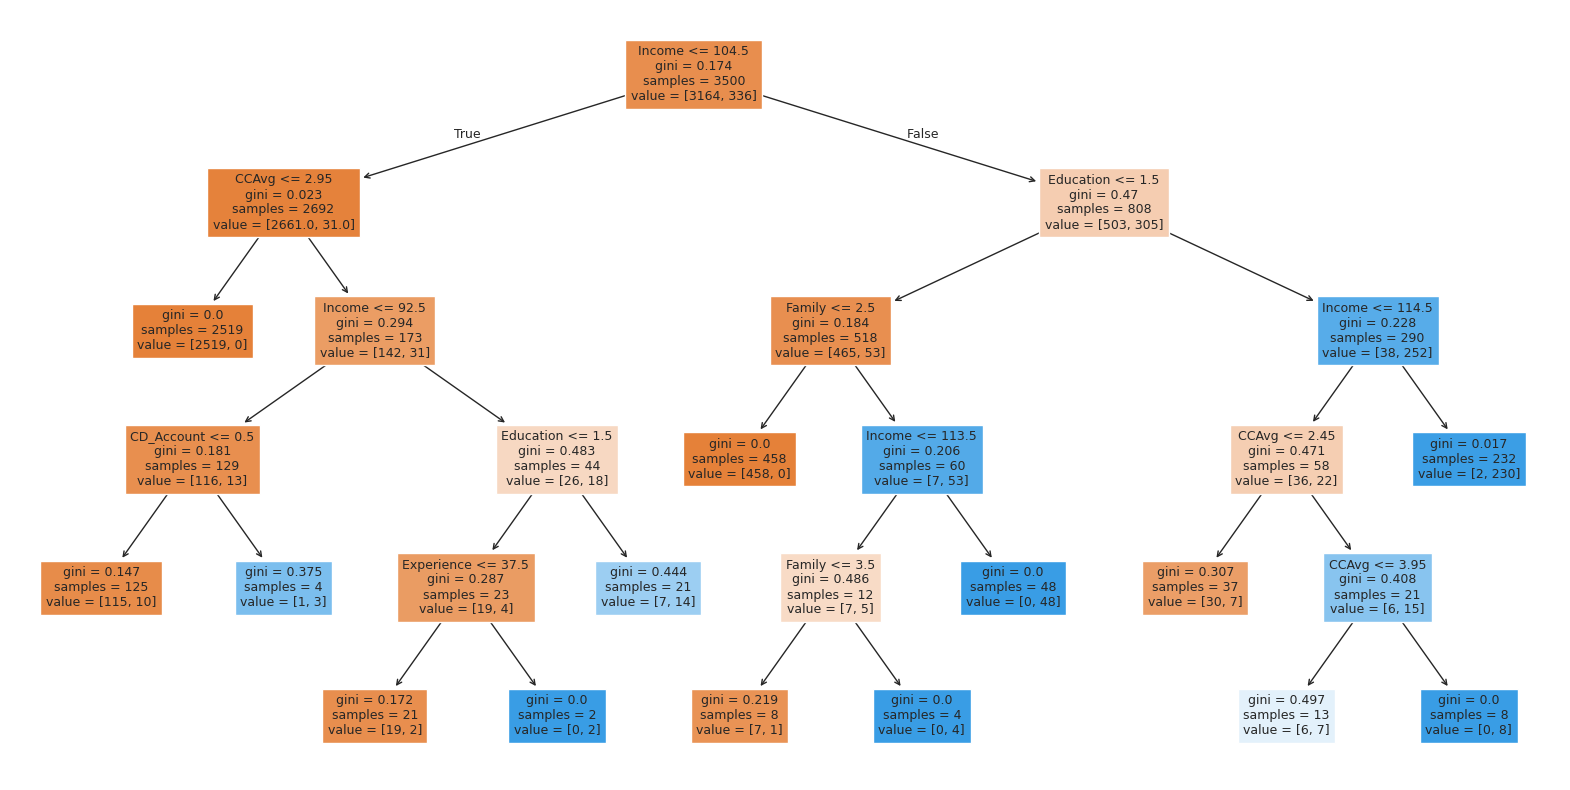

               Feature  Importance
5            Education    0.406228
2               Income    0.388306
3               Family    0.157630
4                CCAvg    0.036097
8           CD_Account    0.006314
1           Experience    0.005425
0                  Age    0.000000
6             Mortgage    0.000000
7   Securities_Account    0.000000
9               Online    0.000000
10          CreditCard    0.000000


In [27]:
# Visualizing the full final model - small enough now to show completely (not just top levels)
plt.figure(figsize=(20, 10))
plot_tree(dt_post_pruned, feature_names=X.columns.tolist(), filled=True, fontsize=9)
plt.show()

# Feature importance for the final, selected model
final_importances = pd.DataFrame({'Feature': X.columns, 'Importance': dt_post_pruned.feature_importances_}).sort_values('Importance', ascending=False)
print(final_importances)

**Final Model — Decision Rules and Feature Importance**

The final pruned tree relies on just two features for its top-level splits: Income and Education. Feature importance confirms these dominate the model's decisions (Education 0.406, Income 0.388), with Family size (0.158) and CCAvg (0.036) playing smaller supporting roles, and CD_Account and Experience contributing marginally (0.006 and 0.005). All other features (Age, Mortgage, Securities_Account, Online, CreditCard) have zero importance in this final model.

This simplicity is a strength, not a weakness: a 5-level tree built almost entirely on Income, Education, Family, and CCAvg is easy to explain to the marketing team as a small set of concrete targeting rules (e.g., "customers earning above $X with a Graduate/Advanced degree are highly likely to accept"), rather than a black-box result.

## Actionable Insights and Business Recommendations


**Key Insights**

* Personal loan acceptance is driven primarily by financial capacity, not demographics. Income and Education level are the two dominant predictors in both the correlation analysis and the final model's feature importance, followed by Family size and monthly credit card spending (CCAvg).
* Customers earning above roughly $100K, particularly those with a Graduate or Advanced/Professional degree, convert at a dramatically higher rate than the rest of the customer base.
* CD_Account ownership is a powerful, if under-used, signal: only 6% of customers hold one, but they accept the loan at nearly 6x the rate of non-holders (46% vs 7%).
* Age, work experience, and existing product usage (Securities_Account, Online banking, holding a credit card from another bank) show almost no relationship with loan acceptance and should not be used as targeting criteria.
* The final pruned decision tree achieves 90.3% Recall and 92.9% Precision on unseen customers — meaning it correctly identifies roughly 9 out of 10 genuine loan-acceptors, and when it flags a customer as likely to accept, it is right about 93% of the time.

**Recommendations to the Marketing Team**

1. **Replace broad campaigns with model-based targeting.** Rather than marketing to depositors uniformly (which produced the 9% baseline conversion rate), score the full depositor base with this model and prioritize outreach to customers it flags as likely acceptors. Since flagged customers convert at ~93% precision versus a 9.6% base rate, this represents roughly a 9-10x improvement in campaign efficiency — far fewer wasted contacts for the same or better number of conversions.
2. **Prioritize high-income, highly-educated customers first.** Customers with income above ~$100K and a Graduate/Advanced degree should be the first segment contacted in any campaign wave, as they show the highest acceptance rates in both the data and the model.
3. **Build a dedicated campaign for CD_Account holders.** This is a small (6%) but extremely high-converting segment (46% acceptance). Even though it won't drive large volume, it offers an outsized return on a small, easy-to-target list — a good candidate for an early, low-cost pilot wave.
4. **De-prioritize age-based and product-usage-based segmentation.** Marketing spend aimed at specific age brackets, securities account holders, or existing credit card users is unlikely to improve conversion, since these show negligible relationship with loan acceptance.
5. **Retrain periodically.** Customer income, spending, and product holdings shift over time, and the model was trained on a single historical snapshot. Re-running this analysis on updated customer data every 6-12 months (or after major campaigns) will keep targeting accurate as the customer base evolves.

**Potential Business Benefit**

If the bank applies this model to its full liability customer base before the next campaign wave, it can concentrate outreach on the ~10-15% of customers most likely to convert rather than contacting everyone indiscriminately. Holding response behavior constant, this should meaningfully raise the campaign's conversion rate above the prior 9% pilot benchmark while reducing the number of customers contacted — lowering marketing cost per acquired loan customer and improving the overall return on the campaign budget.

___